# Proyecto Phoenix: Detección de Fraude en E-Commerce
## IEEE-CIS Fraud Detection Challenge
### Grupo 2

**Equipo**: Diego Alejandro Irreño - David Fernando Lopez - Juan Camilo López – Edda
Camila Rodríguez.


**Objetivo**: El propósito es construir un modelo predictivo de detección de fraude en transacciones de comercio electrónico utilizando tcnicas de *Machine Learning*. Se busca identificar transacciones fraudulentas con alta precisión para proteger tanto a comerciantes como a consumidores en el ecosistema de pagos digitales.

**Origen de los Datos**: [Datos Vesta Corporation](https://www.kaggle.com/competitions/ieee-fraud-detection/data)

**Dataset**: 590,540 transacciones con 434 variables  
**Desbalance**: 3.5% fraude, 96.5% legí­timo



**Nota**: Nos apoyamos con herramientas IA: Copilot, GPT, Gemini para generación de código y corrección de errores y mejora de redacción. 
**Estructura:** Es un dataset de escala industrial compuesto por dos tablas principales: **Transacciones** (datos de pago, montos y variables anonimizadas) e **Identidad** (contexto del dispositivo y red), conectadas por el `TransactionID`.

**Volumen:** Contiene un total de **590,540 registros** y **434 variables**.

**Desafí­o técnico:** Presenta un alto desbalance, donde solo el **3.5%** de las transacciones son fraudulentas.

**Métrica principal:** El modelo se optimiza utilizando el **AUC-ROC** (Ãrea bajo la curva de la caracterí­stica operativa del receptor). Esta métrica es fundamental en este contexto porque permite evaluar el rendimiento del modelo en datos asimétricos o desbalanceados, donde la exactitud simple no es confiable.

---

### Datos interesantes según el análisis exploratorio previo (Incorporado en este notebook):

El documento destaca que ya identificaron variables crÃ­ticas que "separan" bien el fraude:

* El **Producto C** tiene la tasa más alta de fraude (~12%).

* Las **tarjetas de crédito** son m-as vulnerables (~7%) que las de dÃ©bito.

* El uso de **dispositivos móviles** duplica el riesgo de fraude en comparaciÃ³n con computadoras de escritorio (*desktop*).


El siguiente notebook presenta el siguiente orden, lo que permite obtener conclusiones a partir de la exploración inicial, limpieza, ingeniería de características y comparación de varios modelos.

1. Imports e instalación
2. Carga de datos
3. Merge train/test con identity
4. EDA
5. Feature engineering
6. Preprocessing
7. Separación X_train, y_train, X_test
8. FASE 5: SMOTE
9. Variante sin SMOTE
10. Evaluación/modelos
11. Stacking
12. SHAP
13. Submission
14. Guardado de modelos


---
## FASE 1: CONFIGURACIÓN Y CARGA DE DATOS
### Paso 1.1 y 1.2: Importar librerí­as y cargar datos

In [1]:
%pip install -U plotly pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm catboost imbalanced-learn shap joblib nbformat>=5.9


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Data manipulation
import pandas as pd
import numpy as np
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning - Data Processing
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, auc, roc_curve, precision_recall_curve, 
    confusion_matrix, classification_report, f1_score, precision_score, recall_score
)

# Machine Learning - Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Imbalanced Learning
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours as ENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Interpretability
import shap

# Utilities
import warnings
import joblib
from datetime import datetime

warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("âœ“ LibrerÃ­as importadas correctamente")

âœ“ LibrerÃ­as importadas correctamente


c:\Users\eddos\OneDrive\Documentos\2026\Github\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Define paths
data_path = Path('./ieee-fraud-detection')

# Load datasets
print("Cargando datasets...")
train_transaction = pd.read_csv(data_path / 'train_transaction.csv')
train_identity = pd.read_csv(data_path / 'train_identity.csv')
test_transaction = pd.read_csv(data_path / 'test_transaction.csv')
test_identity = pd.read_csv(data_path / 'test_identity.csv')

print(f"âœ“ train_transaction: {train_transaction.shape}")
print(f"âœ“ train_identity: {train_identity.shape}")
print(f"âœ“ test_transaction: {test_transaction.shape}")
print(f"âœ“ test_identity: {test_identity.shape}")

Cargando datasets...
âœ“ train_transaction: (590540, 394)
âœ“ train_identity: (144233, 41)
âœ“ test_transaction: (506691, 393)
âœ“ test_identity: (141907, 41)


In [ ]:
# Merge datasets
print("Mergeando datasets...")
train_data = train_transaction.merge(train_identity, on='TransactionID', how='left')
test_data = test_transaction.merge(test_identity, on='TransactionID', how='left')

print(f"Rows with identity info: {train_data['id_01'].notna().sum()} / {len(train_data)}")


print(f" train_data: {train_data.shape}")
print(f"test_data: {test_data.shape}")
print(f" Merge completado")

Mergeando datasets...
Rows with identity info: 144233 / 590540
âœ“ train_data: (590540, 434)
âœ“ test_data: (506691, 433)

âœ“ Merge completado


### Paso 1.3: Inspección inicial de datos

In [ ]:
# Información general
print("=" * 60)
print("INFORMACIÃ“N GENERAL DEL DATASET")
print("=" * 60)

print(f"\nTrain shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")

print(f"\nTipos de datos:")
print(train_data.dtypes.value_counts())

print(f"\nMemoria usada: {train_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

INFORMACIÃ“N GENERAL DEL DATASET

Train shape: (590540, 434)
Test shape: (506691, 433)

Tipos de datos:
float64    399
str         31
int64        4
Name: count, dtype: int64

Memoria usada: 2513.97 MB


In [6]:
# Primeras filas
print("Primeras 5 filas del dataset:")
print(train_data.head())

Primeras 5 filas del dataset:
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5   card6  addr1  addr2  dist1  dist2  \
0    NaN  150.0    discover  142.0  credit  315.0   87.0   19.0    NaN   
1  404.0  150.0  mastercard  102.0  credit  325.0   87.0    NaN    NaN   
2  490.0  150.0        visa  166.0   debit  330.0   87.0  287.0    NaN   
3  567.0  150.0  mastercard  117.0   debit  476.0   87.0    NaN    NaN   
4  514.0  150.0  mastercard  102.0  credit  420.0   87.0    NaN    NaN   

  P_emaildomain R_emaildomain   C1   C2   C3   C4   C5   C6   

In [7]:
# Valores faltantes
print("\nValores faltantes (Top 20):")
missing_values = train_data.isnull().sum()
missing_percent = (train_data.isnull().sum() / len(train_data)) * 100
missing_df = pd.DataFrame({
    'Columna': missing_values.index,
    'Faltantes': missing_values.values,
    'Porcentaje': missing_percent.values
}).sort_values('Porcentaje', ascending=False).head(20)

print(missing_df.to_string(index=False))


Valores faltantes (Top 20):
Columna  Faltantes  Porcentaje
  id_24     585793   99.196159
  id_25     585408   99.130965
  id_07     585385   99.127070
  id_08     585385   99.127070
  id_21     585381   99.126393
  id_26     585377   99.125715
  id_27     585371   99.124699
  id_23     585371   99.124699
  id_22     585371   99.124699
  dist2     552913   93.628374
     D7     551623   93.409930
  id_18     545427   92.360721
    D13     528588   89.509263
    D14     528353   89.469469
    D12     525823   89.041047
  id_04     524216   88.768923
  id_03     524216   88.768923
     D6     517353   87.606767
  id_33     517251   87.589494
  id_09     515614   87.312290


In [ ]:
# Estadí­sticas descriptivas
print("\nEstadÃ­sticas descriptivas (variables numÃ©ricas):")
print(train_data.describe())


EstadÃ­sticas descriptivas (variables numÃ©ricas):
       TransactionID        isFraud  TransactionDT  TransactionAmt  \
count   5.905400e+05  590540.000000   5.905400e+05   590540.000000   
mean    3.282270e+06       0.034990   7.372311e+06      135.027176   
std     1.704744e+05       0.183755   4.617224e+06      239.162522   
min     2.987000e+06       0.000000   8.640000e+04        0.251000   
25%     3.134635e+06       0.000000   3.027058e+06       43.321000   
50%     3.282270e+06       0.000000   7.306528e+06       68.769000   
75%     3.429904e+06       0.000000   1.124662e+07      125.000000   
max     3.577539e+06       1.000000   1.581113e+07    31937.391000   

               card1          card2          card3          card5  \
count  590540.000000  581607.000000  588975.000000  586281.000000   
mean     9898.734658     362.555488     153.194925     199.278897   
std      4901.170153     157.793246      11.336444      41.244453   
min      1000.000000     100.000000     1

---
## FASE 2: ANÁLISIS EXPLORATORIO (EDA)
### Paso 2.1: Análisis de la variable objetivo

In [9]:
# DistribuciÃ³n de clases
print("=" * 60)
print("DISTRIBUCIÃ“N DE LA VARIABLE OBJETIVO")
print("=" * 60)

fraud_counts = train_data['isFraud'].value_counts()
fraud_percent = train_data['isFraud'].value_counts(normalize=True) * 100

print(f"\nTotal transacciones: {len(train_data):,}")
print(f"\nLegÃ­timas (0): {fraud_counts[0]:,} ({fraud_percent[0]:.2f}%)")
print(f"Fraudulentas (1): {fraud_counts[1]:,} ({fraud_percent[1]:.2f}%)")
print(f"\nRatio desbalance: {fraud_counts[0] / fraud_counts[1]:.2f}:1")

DISTRIBUCIÃ“N DE LA VARIABLE OBJETIVO

Total transacciones: 590,540

LegÃ­timas (0): 569,877 (96.50%)
Fraudulentas (1): 20,663 (3.50%)

Ratio desbalance: 27.58:1


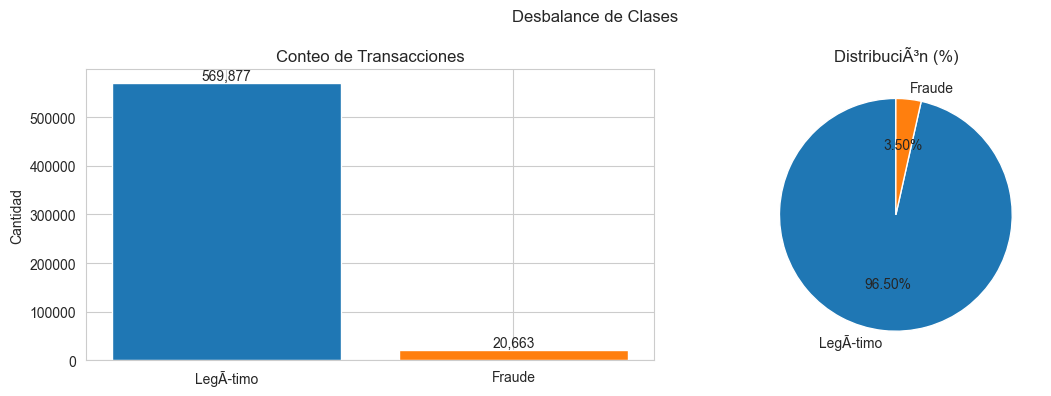


âœ“ GrÃ¡fico de desbalance generado


In [10]:
# VisualizaciÃ³n del desbalance con Matplotlib
import matplotlib.pyplot as plt

class_labels = ['LegÃ­timo', 'Fraude']
class_colors = ['#1f77b4', '#ff7f0e']

fraud_counts_plot = train_data['isFraud'].value_counts().reindex([0, 1], fill_value=0)
values = fraud_counts_plot.to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(class_labels, values, color=class_colors)
axes[0].set_title('Conteo de Transacciones')
axes[0].set_ylabel('Cantidad')

for i, value in enumerate(values):
    axes[0].text(
        i,
        value,
        f'{value:,}',
        ha='center',
        va='bottom'
    )

# Pie chart
axes[1].pie(
    values,
    labels=class_labels,
    colors=class_colors,
    autopct='%1.2f%%',
    startangle=90
)
axes[1].set_title('DistribuciÃ³n (%)')

fig.suptitle('Desbalance de Clases')
plt.tight_layout()
plt.show()

print("\nâœ“ GrÃ¡fico de desbalance generado")


Transacciones por Clase

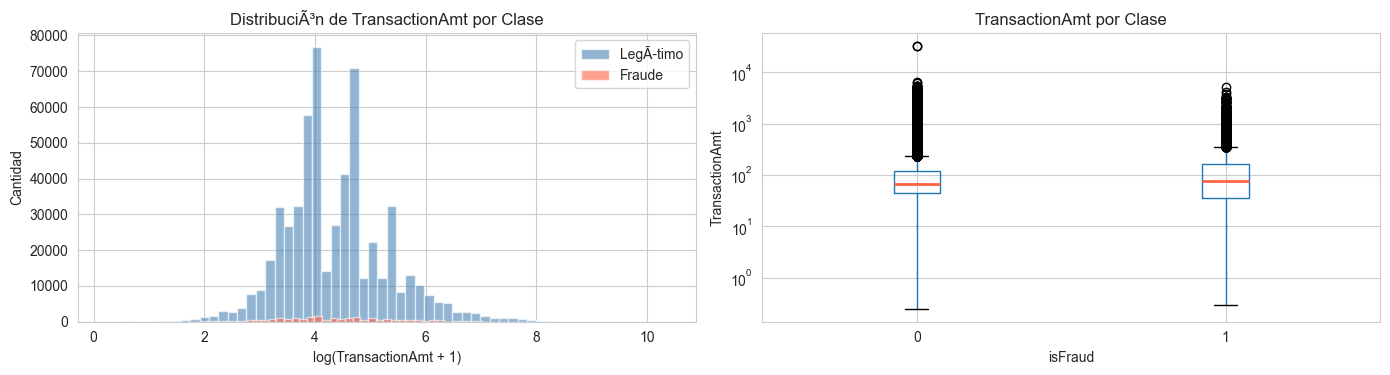

            count    mean     std   min    25%   50%    75%       max
isFraud                                                              
0        569877.0  134.51  239.40  0.25  43.97  68.5  120.0  31937.39
1         20663.0  149.24  232.21  0.29  35.04  75.0  161.0   5191.00


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, color, name in zip([0, 1], ['steelblue', 'tomato'], ['LegÃ­timo', 'Fraude']):
    subset = train_data.loc[train_data['isFraud'] == label, 'TransactionAmt']
    axes[0].hist(
        np.log1p(subset),
        bins=60,
        alpha=0.6,
        label=name,
        color=color
    )

axes[0].set_title('DistribuciÃ³n de TransactionAmt por Clase')
axes[0].set_xlabel('log(TransactionAmt + 1)')
axes[0].set_ylabel('Cantidad')
axes[0].legend()

train_data.boxplot(
    column='TransactionAmt',
    by='isFraud',
    ax=axes[1],
    medianprops=dict(color='tomato', linewidth=2)
)

axes[1].set_yscale('log')
axes[1].set_title('TransactionAmt por Clase')
axes[1].set_xlabel('isFraud')
axes[1].set_ylabel('TransactionAmt')

plt.suptitle('')
plt.tight_layout()
plt.show()

print(train_data.groupby('isFraud')['TransactionAmt'].describe().round(2))


Fraude por variables categoricas

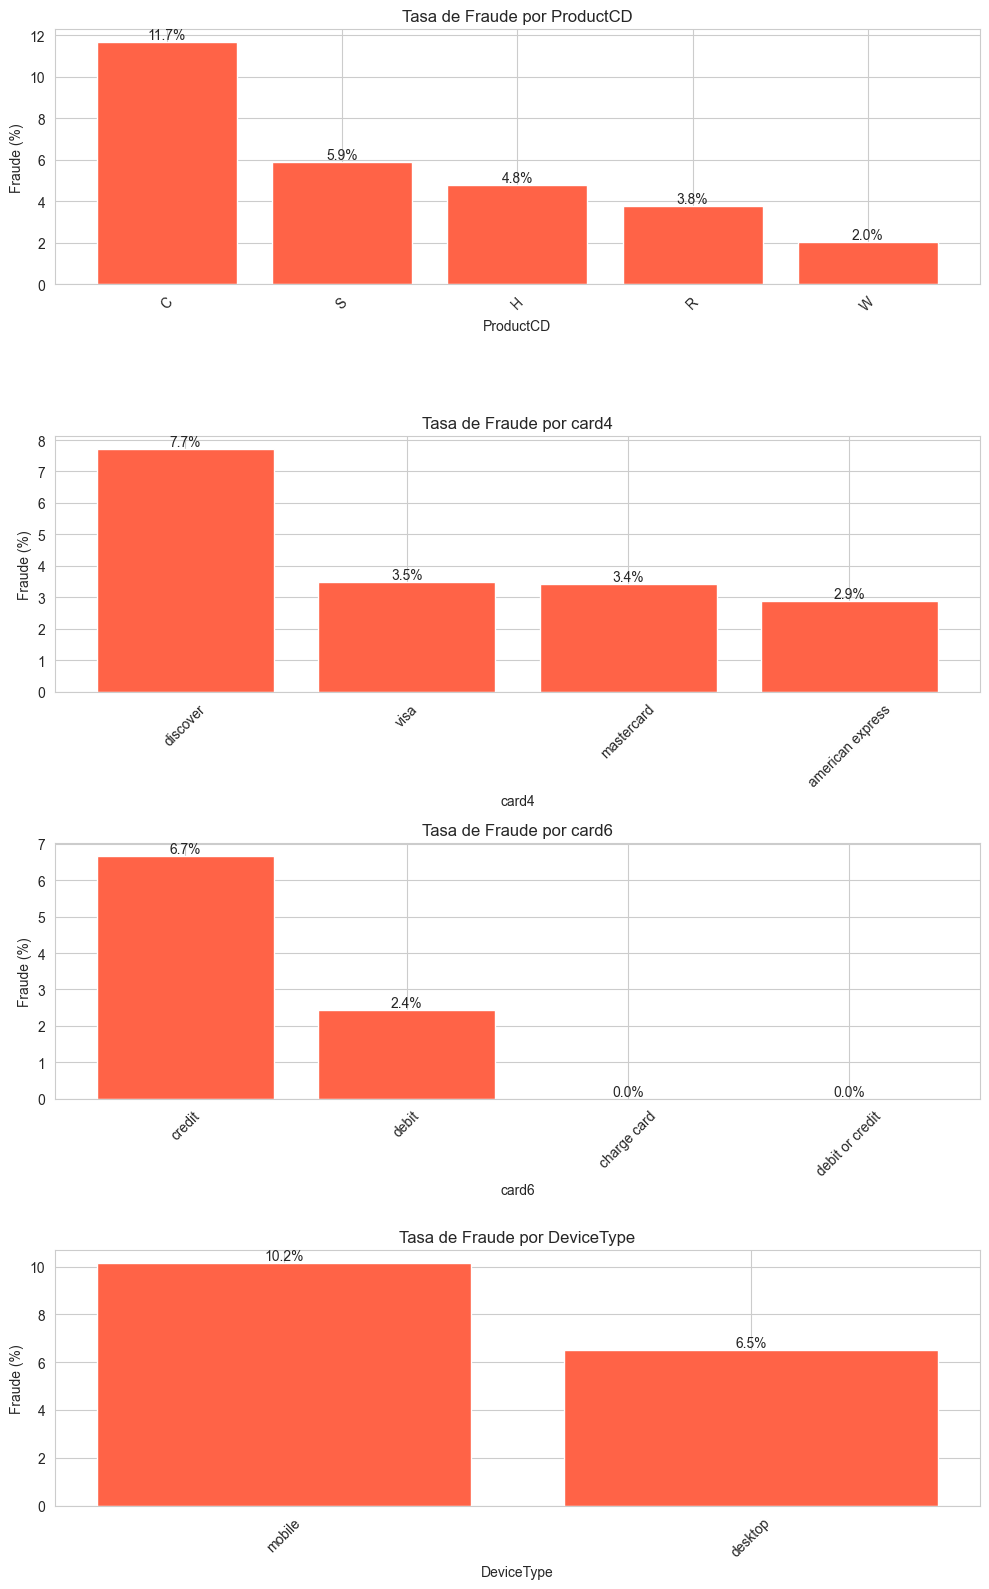

In [12]:
cat_cols = ['ProductCD', 'card4', 'card6', 'DeviceType']

available_cat_cols = [col for col in cat_cols if col in train_data.columns]

fig, axes = plt.subplots(len(available_cat_cols), 1, figsize=(10, 4 * len(available_cat_cols)))

if len(available_cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, available_cat_cols):
    fraud_by_cat = (
        train_data
        .groupby(col)['isFraud']
        .agg(['count', 'mean'])
        .sort_values('mean', ascending=False)
    )

    fraud_by_cat['fraud_rate_pct'] = fraud_by_cat['mean'] * 100

    ax.bar(
        fraud_by_cat.index.astype(str),
        fraud_by_cat['fraud_rate_pct'],
        color='tomato'
    )

    ax.set_title(f'Tasa de Fraude por {col}')
    ax.set_ylabel('Fraude (%)')
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=45)

    for i, value in enumerate(fraud_by_cat['fraud_rate_pct']):
        ax.text(i, value, f'{value:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()


tabla resumen de fraude por categoria

In [13]:
for col in available_cat_cols:
    fraud_by_cat = (
        train_data
        .groupby(col)['isFraud']
        .agg(
            total='count',
            fraudes='sum',
            tasa_fraude='mean'
        )
        .sort_values('tasa_fraude', ascending=False)
    )

    fraud_by_cat['tasa_fraude'] = fraud_by_cat['tasa_fraude'] * 100

    print(f'\nTasa de fraude por {col}:')
    display(fraud_by_cat.round(2))



Tasa de fraude por ProductCD:


,total,fraudes,tasa_fraude
ProductCD,,,
C,68519,8008,11.69
S,11628,686,5.90
H,33024,1574,4.77
R,37699,1426,3.78
W,439670,8969,2.04



Tasa de fraude por card4:


,total,fraudes,tasa_fraude
card4,,,
discover,6651,514,7.73
visa,384767,13373,3.48
mastercard,189217,6496,3.43
american express,8328,239,2.87



Tasa de fraude por card6:


,total,fraudes,tasa_fraude
card6,,,
credit,148986,9950,6.68
debit,439938,10674,2.43
charge card,15,0,0.00
debit or credit,30,0,0.00



Tasa de fraude por DeviceType:


,total,fraudes,tasa_fraude
DeviceType,,,
mobile,55645,5657,10.17
desktop,85165,5554,6.52


Volumen Diario Usando TransactionDT

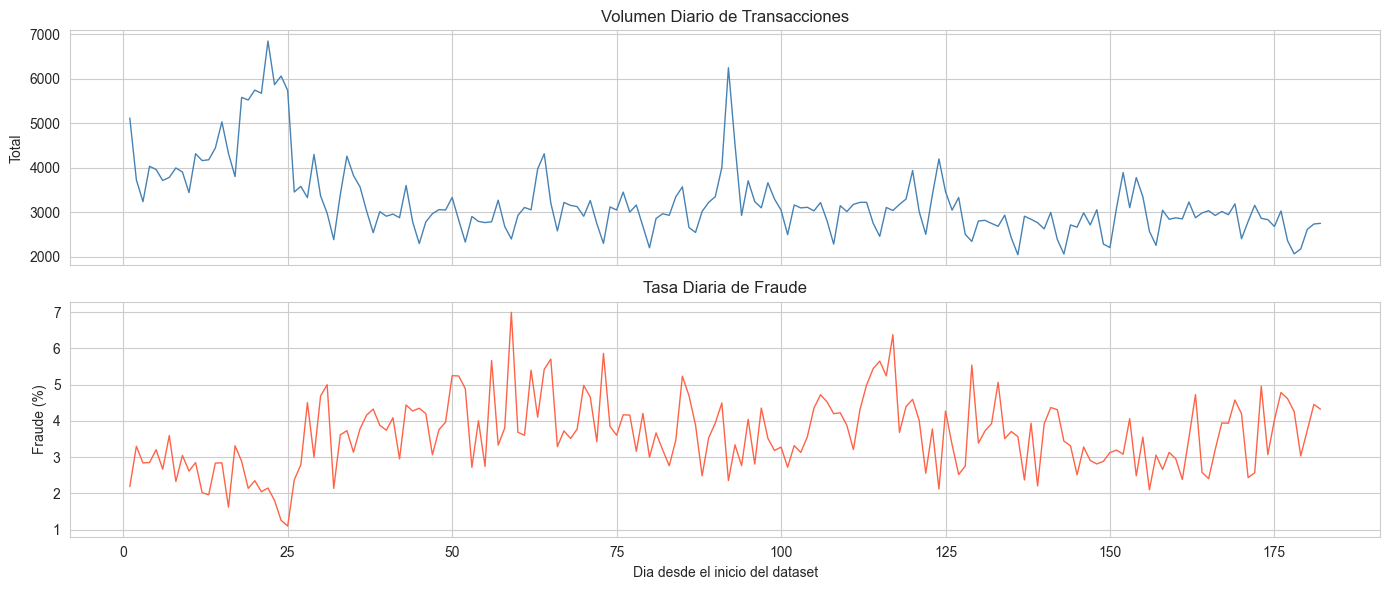

In [14]:
eda_day = train_data['TransactionDT'] // 86400

daily = train_data.groupby(eda_day)['isFraud'].agg(['count', 'sum'])
daily.index.name = 'day'
daily.columns = ['total_transacciones', 'fraudes']
daily['tasa_fraude'] = daily['fraudes'] / daily['total_transacciones'] * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(
    daily.index,
    daily['total_transacciones'],
    color='steelblue',
    linewidth=1
)
axes[0].set_ylabel('Total')
axes[0].set_title('Volumen Diario de Transacciones')

axes[1].plot(
    daily.index,
    daily['tasa_fraude'],
    color='tomato',
    linewidth=1
)
axes[1].set_ylabel('Fraude (%)')
axes[1].set_xlabel('Dia desde el inicio del dataset')
axes[1].set_title('Tasa Diaria de Fraude')

plt.tight_layout()
plt.show()


valores faltantes

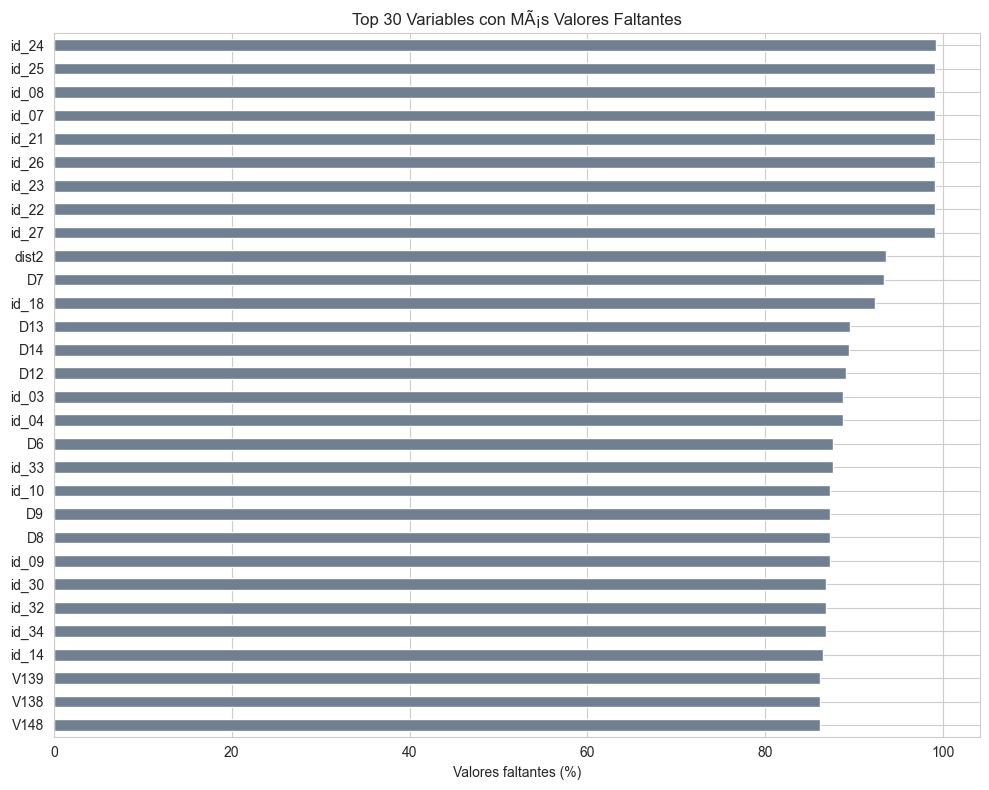

,columna,porcentaje_faltante
0,id_24,99.20
1,id_25,99.13
2,id_07,99.13
3,id_08,99.13
4,id_21,99.13
5,id_26,99.13
6,id_27,99.12
7,id_23,99.12
8,id_22,99.12
9,dist2,93.63


In [15]:
missing = (
    train_data
    .isnull()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_top = missing.head(30)

fig, ax = plt.subplots(figsize=(10, 8))

missing_top.sort_values().plot(
    kind='barh',
    ax=ax,
    color='slategray'
)

ax.set_title('Top 30 Variables con MÃ¡s Valores Faltantes')
ax.set_xlabel('Valores faltantes (%)')

plt.tight_layout()
plt.show()

missing_df = pd.DataFrame({
    'columna': missing.index,
    'porcentaje_faltante': missing.values
})

display(missing_df.head(30).round(2))


correlaciones numericas con isFraud

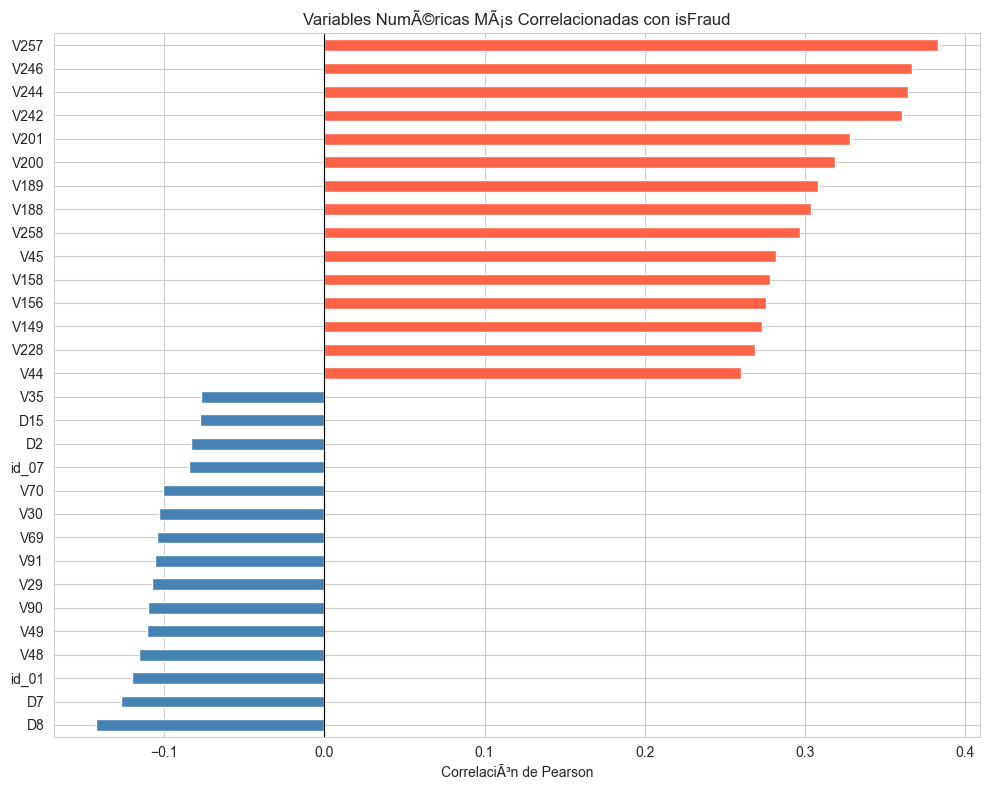

,correlacion_con_isFraud
V257,0.3831
V246,0.3669
V244,0.3641
V242,0.3606
V201,0.3280
V200,0.3188
V189,0.3082
V188,0.3036
V258,0.2972
V45,0.2818


In [16]:
exclude_cols = ['TransactionID', 'TransactionDT', 'day', 'isFraud']

num_cols = (
    train_data
    .select_dtypes(include='number')
    .columns
    .drop([col for col in exclude_cols if col in train_data.columns])
)

corr = train_data[num_cols].corrwith(train_data['isFraud']).dropna()

top_corr = pd.concat([
    corr.nlargest(15),
    corr.nsmallest(15)
]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['tomato' if value > 0 else 'steelblue' for value in top_corr.values]

top_corr.plot(
    kind='barh',
    ax=ax,
    color=colors
)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Variables NumÃ©ricas MÃ¡s Correlacionadas con isFraud')
ax.set_xlabel('CorrelaciÃ³n de Pearson')

plt.tight_layout()
plt.show()

display(
    top_corr
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame('correlacion_con_isFraud')
    .round(4)
)


### Paso 2.2: Análisis por categorías clave

In [ ]:
# Análisis por ProductCD
print("\nTASA DE FRAUDE POR PRODUCTCD:")
fraud_by_product = train_data.groupby('ProductCD').agg({
    'isFraud': ['count', 'sum', 'mean']
}).round(4)
fraud_by_product.columns = ['Total', 'Fraudes', 'Tasa_Fraude']
fraud_by_product['Tasa_Fraude'] = fraud_by_product['Tasa_Fraude'] * 100
fraud_by_product = fraud_by_product.sort_values('Tasa_Fraude', ascending=False)
print(fraud_by_product)


TASA DE FRAUDE POR PRODUCTCD:
            Total  Fraudes  Tasa_Fraude
ProductCD                              
C           68519     8008        11.69
S           11628      686         5.90
H           33024     1574         4.77
R           37699     1426         3.78
W          439670     8969         2.04


In [ ]:
# Análisis por tipo de tarjeta (Card1, Card4, Card6)
print("\nTASA DE FRAUDE POR TIPO DE TARJETA:")
if 'card4' in train_data.columns:
    fraud_by_card = train_data.groupby('card4').agg({
        'isFraud': ['count', 'sum', 'mean']
    }).round(4)
    fraud_by_card.columns = ['Total', 'Fraudes', 'Tasa_Fraude']
    fraud_by_card['Tasa_Fraude'] = fraud_by_card['Tasa_Fraude'] * 100
    fraud_by_card = fraud_by_card.sort_values('Tasa_Fraude', ascending=False)
    print(fraud_by_card)


TASA DE FRAUDE POR TIPO DE TARJETA:
                   Total  Fraudes  Tasa_Fraude
card4                                         
discover            6651      514         7.73
visa              384767    13373         3.48
mastercard        189217     6496         3.43
american express    8328      239         2.87


In [ ]:
# Análisis por DeviceType (Desktop vs Mobile)
print("\nTASA DE FRAUDE POR TIPO DE DISPOSITIVO:")
if 'DeviceType' in train_data.columns:
    fraud_by_device = train_data.groupby('DeviceType').agg({
        'isFraud': ['count', 'sum', 'mean']
    }).round(4)
    fraud_by_device.columns = ['Total', 'Fraudes', 'Tasa_Fraude']
    fraud_by_device['Tasa_Fraude'] = fraud_by_device['Tasa_Fraude'] * 100
    fraud_by_device = fraud_by_device.sort_values('Tasa_Fraude', ascending=False)
    print(fraud_by_device)


TASA DE FRAUDE POR TIPO DE DISPOSITIVO:
            Total  Fraudes  Tasa_Fraude
DeviceType                             
mobile      55645     5657        10.17
desktop     85165     5554         6.52


### Paso 2.3: Análisis de variables numéricas clave

In [ ]:
# TransactionAmt
print("\nCOMPARACIÃ“N DE TransactionAmt (Fraude vs Legítimo):")
print("\nLegÃ­timas:")
print(train_data[train_data['isFraud'] == 0]['TransactionAmt'].describe())
print("\nFraudulentas:")
print(train_data[train_data['isFraud'] == 1]['TransactionAmt'].describe())


COMPARACIÃ“N DE TransactionAmt (Fraude vs LegÃ­timo):

LegÃ­timas:
count    569877.000000
mean        134.511665
std         239.395078
min           0.251000
25%          43.970000
50%          68.500000
75%         120.000000
max       31937.391000
Name: TransactionAmt, dtype: float64

Fraudulentas:
count    20663.000000
mean       149.244779
std        232.212163
min          0.292000
25%         35.044000
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64


In [21]:
# VisualizaciÃ³n de TransactionAmt
fig = go.Figure()

fig.add_trace(go.Box(
    y=train_data[train_data['isFraud'] == 0]['TransactionAmt'],
    name='LegÃ­tima',
    marker_color='#1f77b4'
))

fig.add_trace(go.Box(
    y=train_data[train_data['isFraud'] == 1]['TransactionAmt'],
    name='Fraude',
    marker_color='#ff7f0e'
))

fig.update_layout(title='DistribuciÃ³n de TransactionAmt por Tipo', 
                  yaxis_title='TransactionAmt', height=500)
fig.show()

### Paso 2.4 y 2.5: Correlaciones e importancia de features

In [22]:
# CorrelaciÃ³n de variables numÃ©ricas con target
numeric_cols = train_data.select_dtypes(include=[np.number]).columns
correlations = train_data[numeric_cols].corr()['isFraud'].sort_values(ascending=False)

print("\nTOP 20 VARIABLES MÃS CORRELACIONADAS CON isFraud:")
print(correlations.head(20))


TOP 20 VARIABLES MÃS CORRELACIONADAS CON isFraud:
isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
V44        0.260376
V86        0.251828
V87        0.251737
V170       0.249794
V147       0.242894
Name: isFraud, dtype: float64


In [23]:
# Visualizar top correlaciones
top_corr = correlations.abs().sort_values(ascending=False).head(15)
top_corr_values = correlations[top_corr.index]

fig = go.Figure(data=[
    go.Bar(x=top_corr_values.values, y=top_corr.index, orientation='h',
           marker_color=['#ff7f0e' if x > 0 else '#1f77b4' for x in top_corr_values.values])
])

fig.update_layout(title='Top 15 Variables Correlacionadas con isFraud',
                  xaxis_title='CorrelaciÃ³n', height=500, showlegend=False)
fig.show()

---
## FASE 3: Ingeniería de Características

Esta fase se ejecuta antes del preprocessing para crear variables sobre los datos crudos: centavos del monto, variables temporales, UIDs aproximados, frequency encoding y agregaciones por grupos. 


In [24]:
import gc
import numpy as np
import pandas as pd

print("Iniciando Feature Engineering...")

# Normalizar nombres por si test trae columnas tipo id-01 en vez de id_01
train_data = train_data.rename(columns=lambda col: col.replace('-', '_'))
test_data = test_data.rename(columns=lambda col: col.replace('-', '_'))

y_train = train_data['isFraud'].copy()

X_train_fe = train_data.drop(columns=['isFraud']).copy()
X_test_fe = test_data.copy()

# Alinear columnas base entre train y test
for col in X_train_fe.columns:
    if col not in X_test_fe.columns:
        X_test_fe[col] = np.nan

for col in X_test_fe.columns:
    if col not in X_train_fe.columns:
        X_train_fe[col] = np.nan

X_test_fe = X_test_fe[X_train_fe.columns]

print("Columnas alineadas:")
print("X_train_fe:", X_train_fe.shape)
print("X_test_fe: ", X_test_fe.shape)


Iniciando Feature Engineering...
Columnas alineadas:
X_train_fe: (590540, 433)
X_test_fe:  (506691, 433)


funciones auxiliares

In [25]:
def frequency_encode(train_df, test_df, cols):
    """
    Crea frecuencia relativa usando train + test.
    No usa isFraud, entonces no hay leakage del target.
    """
    for col in cols:
        if col not in train_df.columns or col not in test_df.columns:
            continue

        combined = pd.concat([train_df[col], test_df[col]], axis=0)
        freq_map = combined.value_counts(dropna=False, normalize=True).to_dict()

        new_col = f'{col}_FE'

        train_df[new_col] = train_df[col].map(freq_map).astype('float32')
        test_df[new_col] = test_df[col].map(freq_map).astype('float32')

        print(new_col, end=', ')


def combine_columns(train_df, test_df, col1, col2):
    """
    Crea una variable combinada tipo UID.
    Ejemplo: card1 + addr1.
    """
    if col1 not in train_df.columns or col2 not in train_df.columns:
        return None

    if col1 not in test_df.columns or col2 not in test_df.columns:
        return None

    new_col = f'{col1}_{col2}'

    train_df[new_col] = (
        train_df[col1].astype(str) + '_' + train_df[col2].astype(str)
    )

    test_df[new_col] = (
        test_df[col1].astype(str) + '_' + test_df[col2].astype(str)
    )

    print(new_col, end=', ')
    return new_col


def group_aggregate(train_df, test_df, main_cols, group_cols, aggs=['mean', 'std']):
    """
    Calcula agregaciones de variables numÃ©ricas por grupos tipo UID.
    Ejemplo: promedio de TransactionAmt por card1_addr1.
    """
    for main_col in main_cols:
        if main_col not in train_df.columns or main_col not in test_df.columns:
            continue

        for group_col in group_cols:
            if group_col not in train_df.columns or group_col not in test_df.columns:
                continue

            temp = pd.concat(
                [
                    train_df[[group_col, main_col]],
                    test_df[[group_col, main_col]]
                ],
                axis=0
            )

            for agg in aggs:
                new_col = f'{main_col}_{group_col}_{agg}'

                agg_map = temp.groupby(group_col)[main_col].agg(agg).to_dict()

                train_df[new_col] = train_df[group_col].map(agg_map).astype('float32')
                test_df[new_col] = test_df[group_col].map(agg_map).astype('float32')

                train_df[new_col] = train_df[new_col].fillna(-1)
                test_df[new_col] = test_df[new_col].fillna(-1)

                print(new_col, end=', ')


def group_nunique(train_df, test_df, main_cols, group_cols):
    """
    Cuenta cuÃ¡ntos valores Ãºnicos de una variable aparecen por grupo.
    """
    for main_col in main_cols:
        if main_col not in train_df.columns or main_col not in test_df.columns:
            continue

        for group_col in group_cols:
            if group_col not in train_df.columns or group_col not in test_df.columns:
                continue

            temp = pd.concat(
                [
                    train_df[[group_col, main_col]],
                    test_df[[group_col, main_col]]
                ],
                axis=0
            )

            new_col = f'{group_col}_{main_col}_nunique'
            nunique_map = temp.groupby(group_col)[main_col].nunique().to_dict()

            train_df[new_col] = train_df[group_col].map(nunique_map).astype('float32')
            test_df[new_col] = test_df[group_col].map(nunique_map).astype('float32')

            train_df[new_col] = train_df[new_col].fillna(-1)
            test_df[new_col] = test_df[new_col].fillna(-1)

            print(new_col, end=', ')


In [26]:
print("Creando features de monto...")

if 'TransactionAmt' in X_train_fe.columns:
    for df_ in [X_train_fe, X_test_fe]:
        df_['TransactionAmt_cents'] = (
            df_['TransactionAmt'] - np.floor(df_['TransactionAmt'])
        ).astype('float32')

        df_['TransactionAmt_log'] = np.log1p(df_['TransactionAmt']).astype('float32')

print("TransactionAmt_cents, TransactionAmt_log")


print("\nCreando features temporales...")

if 'TransactionDT' in X_train_fe.columns:
    seconds_per_day = 24 * 60 * 60

    for df_ in [X_train_fe, X_test_fe]:
        df_['Transaction_day'] = (df_['TransactionDT'] // seconds_per_day).astype('int16')
        df_['Transaction_hour'] = ((df_['TransactionDT'] % seconds_per_day) // 3600).astype('int8')
        df_['Transaction_weekday'] = (df_['Transaction_day'] % 7).astype('int8')

print("Transaction_day, Transaction_hour, Transaction_weekday")


Creando features de monto...
TransactionAmt_cents, TransactionAmt_log

Creando features temporales...
Transaction_day, Transaction_hour, Transaction_weekday


In [27]:
print("Frequency encoding:")

freq_cols = [
    'addr1',
    'addr2',
    'card1',
    'card2',
    'card3',
    'card5',
    'P_emaildomain',
    'R_emaildomain',
    'DeviceInfo',
    'id_30',
    'id_31',
    'id_33'
]

frequency_encode(X_train_fe, X_test_fe, freq_cols)


Frequency encoding:
addr1_FE, addr2_FE, card1_FE, card2_FE, card3_FE, card5_FE, P_emaildomain_FE, R_emaildomain_FE, DeviceInfo_FE, id_30_FE, id_31_FE, id_33_FE, 

In [28]:
print("\n\nCreando combinaciones tipo UID:")

created_uid_cols = []

uid_1 = combine_columns(X_train_fe, X_test_fe, 'card1', 'addr1')
if uid_1:
    created_uid_cols.append(uid_1)

uid_2 = combine_columns(X_train_fe, X_test_fe, 'card1_addr1', 'P_emaildomain')
if uid_2:
    created_uid_cols.append(uid_2)

uid_3 = combine_columns(X_train_fe, X_test_fe, 'card1', 'card2')
if uid_3:
    created_uid_cols.append(uid_3)

uid_4 = combine_columns(X_train_fe, X_test_fe, 'card1_card2', 'addr1')
if uid_4:
    created_uid_cols.append(uid_4)

uid_5 = combine_columns(X_train_fe, X_test_fe, 'card1_card2_addr1', 'P_emaildomain')
if uid_5:
    created_uid_cols.append(uid_5)

print("\n\nUIDs creados:")
print(created_uid_cols)




Creando combinaciones tipo UID:
card1_addr1, card1_addr1_P_emaildomain, card1_card2, card1_card2_addr1, card1_card2_addr1_P_emaildomain, 

UIDs creados:
['card1_addr1', 'card1_addr1_P_emaildomain', 'card1_card2', 'card1_card2_addr1', 'card1_card2_addr1_P_emaildomain']


In [29]:
print("Frequency encoding de UIDs:")

frequency_encode(X_train_fe, X_test_fe, created_uid_cols)


Frequency encoding de UIDs:
card1_addr1_FE, card1_addr1_P_emaildomain_FE, card1_card2_FE, card1_card2_addr1_FE, card1_card2_addr1_P_emaildomain_FE, 

In [30]:
print("\n\nAgregaciones por UID:")

main_agg_cols = [
    'TransactionAmt',
    'TransactionAmt_cents',
    'D1',
    'D4',
    'D9',
    'D10',
    'D11',
    'C1',
    'C13'
]

group_cols = [
    'card1',
    'card1_addr1',
    'card1_addr1_P_emaildomain',
    'card1_card2',
    'card1_card2_addr1',
    'card1_card2_addr1_P_emaildomain'
]

group_aggregate(
    X_train_fe,
    X_test_fe,
    main_cols=main_agg_cols,
    group_cols=group_cols,
    aggs=['mean', 'std']
)




Agregaciones por UID:
TransactionAmt_card1_mean, TransactionAmt_card1_std, TransactionAmt_card1_addr1_mean, TransactionAmt_card1_addr1_std, TransactionAmt_card1_addr1_P_emaildomain_mean, TransactionAmt_card1_addr1_P_emaildomain_std, TransactionAmt_card1_card2_mean, TransactionAmt_card1_card2_std, TransactionAmt_card1_card2_addr1_mean, TransactionAmt_card1_card2_addr1_std, TransactionAmt_card1_card2_addr1_P_emaildomain_mean, TransactionAmt_card1_card2_addr1_P_emaildomain_std, TransactionAmt_cents_card1_mean, TransactionAmt_cents_card1_std, TransactionAmt_cents_card1_addr1_mean, TransactionAmt_cents_card1_addr1_std, TransactionAmt_cents_card1_addr1_P_emaildomain_mean, TransactionAmt_cents_card1_addr1_P_emaildomain_std, TransactionAmt_cents_card1_card2_mean, TransactionAmt_cents_card1_card2_std, TransactionAmt_cents_card1_card2_addr1_mean, TransactionAmt_cents_card1_card2_addr1_std, TransactionAmt_cents_card1_card2_addr1_P_emaildomain_mean, TransactionAmt_cents_card1_card2_addr1_P_email

In [31]:
print("\n\nConteos Ãºnicos por grupo:")

group_nunique(
    X_train_fe,
    X_test_fe,
    main_cols=[
        'addr1',
        'addr2',
        'P_emaildomain',
        'R_emaildomain',
        'TransactionAmt'
    ],
    group_cols=[
        'card1',
        'card1_addr1',
        'card1_card2_addr1'
    ]
)




Conteos Ãºnicos por grupo:
card1_addr1_nunique, card1_addr1_addr1_nunique, card1_card2_addr1_addr1_nunique, card1_addr2_nunique, card1_addr1_addr2_nunique, card1_card2_addr1_addr2_nunique, card1_P_emaildomain_nunique, card1_addr1_P_emaildomain_nunique, card1_card2_addr1_P_emaildomain_nunique, card1_R_emaildomain_nunique, card1_addr1_R_emaildomain_nunique, card1_card2_addr1_R_emaildomain_nunique, card1_TransactionAmt_nunique, card1_addr1_TransactionAmt_nunique, card1_card2_addr1_TransactionAmt_nunique, 

In [32]:
print("\n\nFinalizando Feature Engineering...")

X_train_fe = X_train_fe.replace([np.inf, -np.inf], np.nan)
X_test_fe = X_test_fe.replace([np.inf, -np.inf], np.nan)

# Asegurar mismo orden de columnas
X_test_fe = X_test_fe.reindex(columns=X_train_fe.columns, fill_value=np.nan)

# Reconstruir train_data y test_data para que el preprocessing posterior use las nuevas features
train_data = X_train_fe.copy()
train_data['isFraud'] = y_train.values

test_data = X_test_fe.copy()

gc.collect()

print("Feature Engineering terminado")
print("train_data:", train_data.shape)
print("test_data: ", test_data.shape)




Finalizando Feature Engineering...
Feature Engineering terminado
train_data: (590540, 584)
test_data:  (506691, 583)


In [33]:
# Verificacion rapida de features creadas
feature_keywords = [
    '_FE', '_mean', '_std', '_nunique',
    'TransactionAmt_cents', 'TransactionAmt_log',
    'Transaction_day', 'Transaction_hour', 'Transaction_weekday',
    'card1_addr1', 'card1_card2'
]

created_features = [
    col for col in train_data.columns
    if any(keyword in col for keyword in feature_keywords)
]

print(f"Features nuevas disponibles para modelamiento: {len(created_features)}")
print(created_features[:80])


Features nuevas disponibles para modelamiento: 150
['TransactionAmt_cents', 'TransactionAmt_log', 'Transaction_day', 'Transaction_hour', 'Transaction_weekday', 'addr1_FE', 'addr2_FE', 'card1_FE', 'card2_FE', 'card3_FE', 'card5_FE', 'P_emaildomain_FE', 'R_emaildomain_FE', 'DeviceInfo_FE', 'id_30_FE', 'id_31_FE', 'id_33_FE', 'card1_addr1', 'card1_addr1_P_emaildomain', 'card1_card2', 'card1_card2_addr1', 'card1_card2_addr1_P_emaildomain', 'card1_addr1_FE', 'card1_addr1_P_emaildomain_FE', 'card1_card2_FE', 'card1_card2_addr1_FE', 'card1_card2_addr1_P_emaildomain_FE', 'TransactionAmt_card1_mean', 'TransactionAmt_card1_std', 'TransactionAmt_card1_addr1_mean', 'TransactionAmt_card1_addr1_std', 'TransactionAmt_card1_addr1_P_emaildomain_mean', 'TransactionAmt_card1_addr1_P_emaildomain_std', 'TransactionAmt_card1_card2_mean', 'TransactionAmt_card1_card2_std', 'TransactionAmt_card1_card2_addr1_mean', 'TransactionAmt_card1_card2_addr1_std', 'TransactionAmt_card1_card2_addr1_P_emaildomain_mean', 'T

---
## FASE 4: Preprocessing

Después de crear las nuevas variables se imputan faltantes, se codifican categóricas de forma robusta y se escalan variables numéricas. En este punto `train_data` y `test_data` ya contienen las columnas originales más las features nuevas.


In [ ]:
# FUNCIÃ“N: Preprocessing
def preprocess_data(df, is_train=True, scaler=None, encoders=None):
    """
    Preprocesa el dataset:
    - Imputa valores faltantes usando estadÃ­sticas aprendidas en train.
    - Codifica categÃ³ricas tolerando categorÃ­as nuevas en test.
    - Escala numÃ©ricas usando scaler entrenado solo en train.
    """

    df = df.copy()

    # Remover ID antes del modelamiento
    if 'TransactionID' in df.columns:
        df = df.drop('TransactionID', axis=1)

    target_col = 'isFraud' if 'isFraud' in df.columns else None

    if is_train:
        encoders = {}

        feature_cols = [col for col in df.columns if col != target_col]

        numeric_cols = (
            df[feature_cols]
            .select_dtypes(include=[np.number])
            .columns
            .tolist()
        )

        categorical_cols = [
            col for col in feature_cols
            if col not in numeric_cols
        ]

        encoders['feature_cols'] = feature_cols
        encoders['numeric_cols'] = numeric_cols
        encoders['categorical_cols'] = categorical_cols

        # Imputadores aprendidos en train
        encoders['numeric_fill_values'] = {}
        for col in numeric_cols:
            median_value = df[col].median()
            if pd.isna(median_value):
                median_value = 0
            encoders['numeric_fill_values'][col] = median_value

        encoders['categorical_fill_values'] = {}
        for col in categorical_cols:
            mode_values = df[col].dropna().mode()
            fill_value = mode_values.iloc[0] if len(mode_values) > 0 else 'missing'
            encoders['categorical_fill_values'][col] = fill_value

        # Mapas categÃ³ricos aprendidos en train
        encoders['category_maps'] = {}
        for col in categorical_cols:
            filled_col = (
                df[col]
                .fillna(encoders['categorical_fill_values'][col])
                .astype(str)
            )

            unique_values = sorted(filled_col.unique())
            encoders['category_maps'][col] = {
                value: index for index, value in enumerate(unique_values)
            }

    else:
        if scaler is None or encoders is None:
            raise ValueError("Para procesar test debes pasar scaler y encoders entrenados en train.")

        feature_cols = encoders['feature_cols']
        numeric_cols = encoders['numeric_cols']
        categorical_cols = encoders['categorical_cols']

        # Si alguna columna de train no estÃ¡ en test, se crea vacÃ­a para imputarla
        for col in feature_cols:
            if col not in df.columns:
                df[col] = np.nan

        # Eliminar columnas extra y respetar el mismo orden de train
        cols_to_keep = feature_cols.copy()
        if target_col is not None:
            cols_to_keep.append(target_col)

        df = df[cols_to_keep]

    # ImputaciÃ³n numÃ©rica
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(encoders['numeric_fill_values'][col])

    # Encoding categÃ³rico robusto
    for col in categorical_cols:
        df[col] = (
            df[col]
            .fillna(encoders['categorical_fill_values'][col])
            .astype(str)
            .map(encoders['category_maps'][col])
            .fillna(-1)
            .astype(int)
        )

    # Escalado
    if is_train:
        scaler = RobustScaler()
        df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    else:
        df[numeric_cols] = scaler.transform(df[numeric_cols])

    if is_train:
        return df, scaler, encoders
    else:
        return df

print("âœ“ FunciÃ³n de preprocessing definida")


In [ ]:
print("Aplicando preprocessing al conjunto de entrenamiento...")
train_data_processed, scaler, encoders = preprocess_data(train_data, is_train=True)
print(f"âœ“ train_data_processed: {train_data_processed.shape}")
print("Aplicando preprocessing al conjunto de test...")
test_data_processed = preprocess_data(
    test_data,
    is_train=False,
    scaler=scaler,
    encoders=encoders
)

print(f"âœ“ test_data_processed: {test_data_processed.shape}")

In [ ]:
# Separar features y target
X_train = train_data_processed.drop('isFraud', axis=1)
y_train = train_data_processed['isFraud']
X_test = test_data_processed.copy()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nâœ“ SeparaciÃ³n de features y target completada")

---
## FASE 5: MANEJO DEL DESBALANCE
### Pasos 5.1 a 5.4: SMOTE, ADASYN y configuraciÃ³n de mÃ©tricas

In [ ]:
# FUNCIÃ“N: Aplicar SMOTE + Tomek links
def apply_smote_adasyn(X, y, random_state=RANDOM_STATE):
    """
    Aplica SMOTE combinado con Tomek links para balancear clases
    """
    smt = SMOTE(random_state=random_state, k_neighbors=5)
    tkl = TomekLinks(sampling_strategy='majority')
    
    X_balanced, y_balanced = smt.fit_resample(X, y)
    X_balanced, y_balanced = tkl.fit_resample(X_balanced, y_balanced)
    
    return X_balanced, y_balanced

# Aplicar balanceo
print("Aplicando SMOTE + Tomek links...")
X_train_balanced, y_train_balanced = apply_smote_adasyn(X_train, y_train)

print(f"\nAntes del balanceo:")
print(y_train.value_counts())

print(f"\nDespuÃ©s del balanceo:")
print(y_train_balanced.value_counts())

print(f"\nâœ“ Balanceo completado")
print(f"X_train_balanced shape: {X_train_balanced.shape}")

### Variante sin SMOTE

Esta variante conserva la distribución original de clases y usa `scale_pos_weight` para que XGBoost tenga en cuenta el desbalance sin crear ejemplos sintéticos. Sirve como comparación directa contra el flujo con SMOTE.


In [ ]:
# Dataset alternativo sin balanceo manual
X_train_no_smote = X_train.copy()
y_train_no_smote = y_train.copy()

scale_pos_weight_no_smote = (
    (y_train_no_smote == 0).sum() / max((y_train_no_smote == 1).sum(), 1)
)

print("Variante sin SMOTE preparada")
print(f"X_train_no_smote shape: {X_train_no_smote.shape}")
print(y_train_no_smote.value_counts())
print(f"scale_pos_weight: {scale_pos_weight_no_smote:.2f}")


---
## FASE 6: COMPARACIÃ“N DE MODELOS INDIVIDUALES
### Pasos 6.1 a 6.6: Entrenar y evaluar modelos base

In [ ]:
# FUNCIÃ“N: Evaluar modelo
def evaluate_model(y_true, y_pred_proba, y_pred, model_name):
    """
    Calcula todas las mÃ©tricas importantes para clasificaciÃ³n desbalanceada
    """
    auc_roc = roc_auc_score(y_true, y_pred_proba)
    
    # AUC-PR
    precision_vals, recall_vals, _ = precision_recall_curve(y_true, y_pred_proba)
    auc_pr = auc(recall_vals, precision_vals)
    
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    return {
        'Modelo': model_name,
        'AUC-ROC': auc_roc,
        'AUC-PR': auc_pr,
        'PrecisiÃ³n': precision,
        'Recall': recall,
        'F1-Score': f1
    }

print("âœ“ FunciÃ³n de evaluaciÃ³n definida")

In [ ]:
# Entrenar una variante XGBoost sin SMOTE
print("Entrenando XGBoost sin SMOTE...")

xgb_no_smote = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight_no_smote,
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    eval_metric='auc',
    verbosity=0
)

xgb_no_smote.fit(X_train_no_smote, y_train_no_smote)

y_pred_no_smote = xgb_no_smote.predict(X_train_no_smote)
y_pred_proba_no_smote = xgb_no_smote.predict_proba(X_train_no_smote)[:, 1]

no_smote_result = evaluate_model(
    y_train_no_smote,
    y_pred_proba_no_smote,
    y_pred_no_smote,
    'XGBoost sin SMOTE'
)

no_smote_results_df = pd.DataFrame([no_smote_result])
print("Resultado variante sin SMOTE:")
print(no_smote_results_df.to_string(index=False))


In [ ]:
# Entrenamiento de modelos base
print("=" * 60)
print("FASE 6: ENTRENAMIENTO DE MODELOS BASE")
print("=" * 60)

results = []
models = {}

# 1. Decision Tree
print("\nEntrenando Decision Tree...")
dt = DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=15)
dt.fit(X_train_balanced, y_train_balanced)
y_pred_dt = dt.predict(X_train)  # Predecir en train original para evaluaciÃ³n
y_pred_proba_dt = dt.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_dt, y_pred_dt, 'Decision Tree'))
models['Decision Tree'] = dt
print("âœ“ Decision Tree entrenado")

# 2. Logistic Regression
print("Entrenando Logistic Regression...")
lr = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000)
lr.fit(X_train_balanced, y_train_balanced)
y_pred_lr = lr.predict(X_train)
y_pred_proba_lr = lr.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_lr, y_pred_lr, 'Logistic Regression'))
models['Logistic Regression'] = lr
print("âœ“ Logistic Regression entrenado")

In [ ]:
# 3. Random Forest
print("Entrenando Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, 
                           max_depth=15, class_weight='balanced', n_jobs=-1)
rf.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf.predict(X_train)
y_pred_proba_rf = rf.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_rf, y_pred_rf, 'Random Forest'))
models['Random Forest'] = rf
print("âœ“ Random Forest entrenado")

# 4. XGBoost
print("Entrenando XGBoost...")
xgb_model = xgb.XGBClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    verbosity=0
)
xgb_model.fit(X_train_balanced, y_train_balanced)
y_pred_xgb = xgb_model.predict(X_train)
y_pred_proba_xgb = xgb_model.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_xgb, y_pred_xgb, 'XGBoost'))
models['XGBoost'] = xgb_model
print("âœ“ XGBoost entrenado")

In [ ]:
# 5. LightGBM
print("Entrenando LightGBM...")
lgb_model = lgb.LGBMClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]),
    max_depth=6,
    learning_rate=0.1,
    n_estimators=100,
    verbose=-1
)
lgb_model.fit(X_train_balanced, y_train_balanced)
y_pred_lgb = lgb_model.predict(X_train)
y_pred_proba_lgb = lgb_model.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_lgb, y_pred_lgb, 'LightGBM'))
models['LightGBM'] = lgb_model
print("âœ“ LightGBM entrenado")

# 6. CatBoost
print("Entrenando CatBoost...")
cat_model = CatBoostClassifier(
    random_state=RANDOM_STATE,
    scale_pos_weight=len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1]),
    max_depth=6,
    iterations=100,
    verbose=0
)
cat_model.fit(X_train_balanced, y_train_balanced)
y_pred_cat = cat_model.predict(X_train)
y_pred_proba_cat = cat_model.predict_proba(X_train)[:, 1]
results.append(evaluate_model(y_train, y_pred_proba_cat, y_pred_cat, 'CatBoost'))
models['CatBoost'] = cat_model
print("âœ“ CatBoost entrenado")

In [ ]:
# ComparaciÃ³n de modelos
results_df = pd.DataFrame(results)

print("\n" + "=" * 100)
print("RESUMEN DE RESULTADOS - MODELOS BASE")
print("=" * 100)
print(results_df.to_string(index=False))
print("=" * 100)

# Identificar top 3 modelos por AUC-ROC
top_3_models = results_df.nlargest(3, 'AUC-ROC')['Modelo'].tolist()
print(f"\nTop 3 modelos por AUC-ROC: {top_3_models}")

In [ ]:
# Visualizar comparaciÃ³n
metrics = ['AUC-ROC', 'AUC-PR', 'PrecisiÃ³n', 'Recall', 'F1-Score']

fig = go.Figure()

for metric in metrics:
    fig.add_trace(go.Scatter(
        x=results_df['Modelo'],
        y=results_df[metric],
        mode='lines+markers',
        name=metric,
        line=dict(width=2),
        marker=dict(size=8)
    ))

fig.update_layout(
    title='ComparaciÃ³n de Modelos - Todas las MÃ©tricas',
    xaxis_title='Modelo',
    yaxis_title='Score',
    height=500,
    hovermode='x unified'
)
fig.show()

---
## FASE 7: ENSEMBLE CON STACKING
### Pasos 7.1 a 7.5: Implementar meta-learner

In [ ]:
# FUNCIÃ“N: Implementar Stacking
def create_stacking_features(X, base_models, is_train=False):
    """
    Genera features de meta-nivel para stacking
    """
    stacking_features = []
    
    for model_name, model in base_models.items():
        if is_train:
            pred = model.predict_proba(X)[:, 1]
        else:
            pred = model.predict_proba(X)[:, 1]
        
        stacking_features.append(pred)
    
    return np.column_stack(stacking_features)

print("âœ“ FunciÃ³n de stacking definida")

In [ ]:
# Preparar modelos base para stacking (Top 3)
base_models_stacking = {name: models[name] for name in top_3_models}

print(f"Modelos base para stacking: {list(base_models_stacking.keys())}")

# Generar features de meta-nivel
X_meta_train = create_stacking_features(X_train, base_models_stacking, is_train=True)
X_meta_test = create_stacking_features(X_test, base_models_stacking, is_train=False)

print(f"\nX_meta_train shape: {X_meta_train.shape}")
print(f"X_meta_test shape: {X_meta_test.shape}")

In [ ]:
# Entrenar meta-learner (Logistic Regression)
print("\nEntrenando meta-learner...")
meta_learner = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
meta_learner.fit(X_meta_train, y_train)

# EvaluaciÃ³n del stacking
y_pred_stacking = meta_learner.predict(X_meta_train)
y_pred_proba_stacking = meta_learner.predict_proba(X_meta_train)[:, 1]

stacking_result = evaluate_model(y_train, y_pred_proba_stacking, y_pred_stacking, 'Stacking Ensemble')

print("\n" + "=" * 60)
print("RESULTADO DEL STACKING ENSEMBLE")
print("=" * 60)
for metric, value in stacking_result.items():
    if metric != 'Modelo':
        print(f"{metric}: {value:.4f}")

# Comparar con mejor modelo individual
best_individual = results_df.loc[results_df['AUC-ROC'].idxmax()]
print(f"\nMejor modelo individual: {best_individual['Modelo']} (AUC-ROC: {best_individual['AUC-ROC']:.4f})")
print(f"Stacking ensemble: AUC-ROC: {stacking_result['AUC-ROC']:.4f}")
print(f"Mejora: {(stacking_result['AUC-ROC'] - best_individual['AUC-ROC']) * 100:.2f}%")

---
## FASE 8: INTERPRETABILIDAD CON SHAP
### Pasos 8.1 a 8.4: AnÃ¡lisis de factores de riesgo

In [ ]:
# SHAP Values para mejor modelo individual
best_model_name = results_df.loc[results_df['AUC-ROC'].idxmax(), 'Modelo']
best_model = models[best_model_name]

print(f"Generando SHAP values para {best_model_name}...")
print("(Esto puede tomar un tiempo para bases de datos grandes)")

# Usar muestra para velocidad si dataset es muy grande
sample_size = min(5000, len(X_train))
X_sample = X_train.sample(n=sample_size, random_state=RANDOM_STATE)

if best_model_name in ['XGBoost', 'LightGBM', 'CatBoost']:
    explainer = shap.TreeExplainer(best_model)
else:
    explainer = shap.Explainer(best_model, X_sample)

shap_values = explainer.shap_values(X_sample)
print("âœ“ SHAP values generados")

In [ ]:
# Feature importance global
print("\nPlotting SHAP Summary (por magnitud)...")
shap.summary_plot(shap_values, X_sample, max_display=15, show=False)
plt.tight_layout()
plt.show()
print("âœ“ GrÃ¡fico de importancia SHAP generado")

In [ ]:
# SHAP Dependence plot (impacto de features)
print("\nGenerando dependence plots...")
# Tomar top 3 features
top_features_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-3:][::-1]
feature_names = X_sample.columns.tolist()

for idx in top_features_idx:
    shap.dependence_plot(idx, shap_values, X_sample, show=False)
    plt.show()

print("âœ“ Dependence plots generados")

---
## FASE 9: VALIDACIÃ“N FINAL Y PREDICCIONES EN TEST
### Pasos 9.1 a 9.4: EvaluaciÃ³n final

In [ ]:
# Predicciones en test con stacking ensemble
print("Generando predicciones en conjunto de test...")
y_pred_test_proba = meta_learner.predict_proba(X_meta_test)[:, 1]
y_pred_test = (y_pred_test_proba >= 0.5).astype(int)  # Threshold por defecto 0.5

print(f"\nDistribuciÃ³n de predicciones en test:")
print(f"Predicciones negativas (0): {(y_pred_test == 0).sum():,}")
print(f"Predicciones positivas (1): {(y_pred_test == 1).sum():,}")
print(f"Porcentaje predicho como fraude: {(y_pred_test == 1).sum() / len(y_pred_test) * 100:.2f}%")

---
## FASE 10: GENERACIÃ“N DE SUBMISSION
### Pasos 10.1 a 10.3: Guardar resultados

In [ ]:
# Preparar submission
submission = pd.DataFrame({
    'TransactionID': test_transaction['TransactionID'].values,
    'isFraud': y_pred_test_proba
})

# Guardar submission
submission_path = 'submission.csv'
submission.to_csv(submission_path, index=False)

print(f"âœ“ Submission guardado en {submission_path}")
print(f"\nPrimeras 10 filas:")
print(submission.head(10))

In [ ]:
# Guardar modelos entrenados
print("\nGuardando modelos entrenados...")
joblib.dump(base_models_stacking, 'base_models.pkl')
joblib.dump(meta_learner, 'meta_learner.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoders, 'encoders.pkl')

if 'xgb_no_smote' in globals():
    joblib.dump(xgb_no_smote, 'xgb_no_smote.pkl')

print("✓ Modelos guardados:")
print("  - base_models.pkl")
print("  - meta_learner.pkl")
print("  - scaler.pkl")
print("  - encoders.pkl")
if 'xgb_no_smote' in globals():
    print("  - xgb_no_smote.pkl")


---
## RESUMEN FINAL Y DOCUMENTACIÃ“N

In [ ]:
# Resumen del proyecto
print("\n" + "=" * 80)
print(" " * 20 + "RESUMEN FINAL DEL PROYECTO")
print("=" * 80)

print("\nðŸ“Š DATASET:")
print(f"   - Registros de entrenamiento: {len(train_data):,}")
print(f"   - Registros de test: {len(test_data):,}")
print(f"   - Variables totales: {train_data.shape[1]}")
print(f"   - Desbalance: 3.5% fraude")

print("\nðŸ”§ PREPROCESSING:")
print(f"   - Manejo de valores faltantes: âœ“")
print(f"   - Encoding de categÃ³ricas: âœ“")
print(f"   - Escalado RobustScaler: âœ“")

print("\nâš–ï¸ BALANCEO DE CLASES:")
print(f"   - TÃ©cnica: SMOTE + Tomek Links")
print(f"   - Muestras despuÃ©s del balanceo: {len(X_train_balanced):,}")

print("\nðŸ¤– MODELOS ENTRENADOS:")
for i, row in results_df.iterrows():
    print(f"   {i+1}. {row['Modelo']}")
    print(f"      AUC-ROC: {row['AUC-ROC']:.4f} | PrecisiÃ³n: {row['PrecisiÃ³n']:.4f} | Recall: {row['Recall']:.4f}")

print("\nðŸ† MODELO FINAL:")
print(f"   - Arquitectura: Stacking Ensemble")
print(f"   - Base Learners: {', '.join(top_3_models)}")
print(f"   - Meta-Learner: Logistic Regression")
print(f"   - AUC-ROC: {stacking_result['AUC-ROC']:.4f}")
print(f"   - AUC-PR: {stacking_result['AUC-PR']:.4f}")
print(f"   - PrecisiÃ³n: {stacking_result['PrecisiÃ³n']:.4f}")
print(f"   - Recall: {stacking_result['Recall']:.4f}")
print(f"   - F1-Score: {stacking_result['F1-Score']:.4f}")

print("\nðŸ“ ARCHIVOS GENERADOS:")
print(f"   - submission.csv (predicciones en test)")
print(f"   - base_models.pkl (modelos base)")
print(f"   - meta_learner.pkl (meta-learner)")
print(f"   - scaler.pkl (escalador)")
print(f"   - encoders.pkl (encoders)")

print("\n" + "=" * 80)
print("âœ“ PROYECTO COMPLETADO")
print("=" * 80)